# Batch Layer Norms and Residual Connections

Deep neural networks are highly capable, but they can be difficult to train. As signals pass through many layers, the distribution of activations tends to drift, gradients can vanish or explode, and training can become slow and unstable. Over the years, several techniques have been developed to keep training fast and stable. In this notebook we look at two of the most important:

- **Normalization layers.** These rescale the activations so that each layer receives inputs on a consistent, well-behaved scale. We cover four kinds: *batch*, *layer*, *group*, and *instance* normalization.
- **Residual (skip) connections.** These add a layer's input back to its output, giving gradients a direct path through the network and making very deep models trainable.

<img src="https://d2l.ai/_images/functionclasses.svg" width="720">

**How nesting function classes lets a bigger model find a better function.** Each blob ($\mathcal{F}_1, \mathcal{F}_2, \dots$) is the set of every function a model could learn, called its **function class**, and the blue star is the ideal function we want. Training simply finds the point in a blob closest to the star, so a model is only as good as how close its blob can reach.

- **Left (non-nested).** As the model grows, the blobs slide around without containing one another. A bigger blob can actually land *farther* from the star than a smaller one did, so making the network bigger can make it **worse**.
- **Right (nested).** Each bigger blob fully contains the smaller one ($\mathcal{F}_1 \subset \mathcal{F}_2 \subset \dots$), so its best function can only **improve or stay the same**. Adding capacity is now safe.

**Residual connections build this nesting into a deep network.** A residual block computes $\text{output} = F(x) + x$. If the extra layers add nothing useful, the network can drive $F(x) \to 0$ and pass the input through unchanged (an *identity* mapping), which is exactly what makes each deeper network contain the shallower one. Plain deep networks struggle to learn that identity, which is why naively stacking layers can hurt accuracy. We cover the mechanics in the **Residual Connections** section below.

## What Normalization Does and Why Deep Networks Need It

As data flows forward through a deep network, every layer transforms it, and the **distribution of those activations keeps changing**. It drifts in mean and stretches or shrinks in scale. These changes also compound, because a small shift early on gets amplified layer after layer. That creates several practical problems:

- **Unstable gradients.** When activations wander into very large or very small ranges, gradients tend to explode or vanish, so training becomes slow or diverges.
- **A moving target for every layer.** Each layer must constantly re-adapt to the shifting distribution of its inputs (sometimes called *internal covariate shift*) instead of settling into a good solution.
- **Fragility.** With nothing keeping activations in check, training becomes sensitive to the choice of initialization and learning rate. Get them wrong and the model fails to train appropriately.

**Normalization** tackles all of this with one simple idea: at chosen points in the network, **rescale the activations to a stable, well-behaved distribution** (roughly zero mean and unit variance) before passing them on. For some chosen set of values, every normalization method does exactly three things:

1. Compute their **mean** $\mu$ and **variance** $\sigma^2$.
2. **Standardize** them so they are centered and scaled: $\;\hat{x} = \dfrac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$.
3. Apply a learnable **scale** $\gamma$ and **shift** $\beta$: $\;y = \gamma\hat{x} + \beta$, so the network can recover whatever distribution it actually needs (even the original one).

The four methods we cover (batch, layer, group, and instance normalization) all follow these same three steps. They differ only in **which set of values gets pooled together** to compute the mean and variance, as the figure below shows:

![](https://theaisummer.com/static/ac89fbcf1c115f07ae68af695c28c4a0/ee604/normalization.png)

*Each cube is a batch of activations, with axes for the mini-batch samples (N), the channels (C), and the merged spatial dimensions (H, W). The shaded voxels are the values pooled together to compute a single mean/variance: **batch norm** pools over N and (H, W) for each channel; **layer norm** pools over C and (H, W) for each sample; **instance norm** pools over (H, W) for one channel of one sample; and **group norm** pools over a group of channels and (H, W) for each sample.*

A normalization step is usually inserted *inside* a layer block, between the linear transformation and the activation function (we look at exactly where, and how it differs between frameworks, in a later section). The payoff is faster, more stable training. You can use higher learning rates, worry far less about initialization, and often get a mild regularizing effect. With that foundation in place, we now look at each method in turn, starting with the one that began it all: **batch normalization**.

## Batch Normalization

Batch normalization was introduced by Ioffe and Szegedy (2015) to stabilize and speed up the training of deep networks.

The key idea is to normalize **each feature (or channel) across the examples in a mini-batch**. For a single feature, batch norm gathers that feature's value over every sample in the current batch, computes the mean and variance of those values, and rescales them to have mean 0 and variance 1. It does this independently for each feature. (For convolutional layers the statistics are also pooled over the spatial positions, so the mean and variance are computed *per channel*.)

Why does this help? As the weights update during training, the distribution of each layer's inputs keeps shifting, so every layer is constantly chasing a moving target. By re-centering and re-scaling the activations on every batch, batch norm keeps these distributions stable, which smooths the loss surface and lets you train faster and with higher learning rates.

After normalizing, two learnable parameters are applied: a scale ($\gamma$) and a shift ($\beta$). These let the network partly or fully undo the normalization if that turns out to be better. During **inference**, fixed running averages of the mean and variance (collected during training) are used instead of batch statistics, so a prediction does not depend on the other examples that happen to share its batch.

In the comparison figure above, batch norm corresponds to pooling the values across the **mini-batch (N)** and the spatial **(H, W)** axes, separately for each channel.

![](https://miro.medium.com/v2/resize:fit:898/0*pSSzicm1IH4hXOHc.png)

### The Process

In batch normalization, we adjust the activations within a mini-batch so that they have a mean of zero and a variance of one. Suppose you have a mini-batch containing $m$ examples, and you consider a particular activation $x$ (which could be a scalar value from a feature map or fully connected layer). The steps are as follows:

1. **Compute the Mean:**  
   For the mini-batch, the mean $\mu_B$ is calculated by summing all the values and dividing by the number of samples:
   $$
   \mu_B = \frac{1}{m} \sum_{i=1}^{m} x^{(i)}.
   $$
   This average value represents the central tendency of the activations within the batch.

2. **Compute the Variance:**  
   Next, the variance $\sigma_B^2$ measures how much the activations vary around the mean:
   $$
   \sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} \left( x^{(i)} - \mu_B \right)^2.
   $$
   The variance gives us an idea of the spread or dispersion of the activation values.

3. **Normalize the Activations:**  
   Each activation is normalized by subtracting the mean and dividing by the square root of the variance (plus a small constant $\epsilon$ for numerical stability). This yields:
   $$
   \hat{x}^{(i)} = \frac{x^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}.
   $$
   Here, the term $\sqrt{\sigma_B^2 + \epsilon}$ ensures that even if the variance is very small, we avoid division by zero.

4. **Apply Learnable Scaling and Shifting:**  
   After normalization, the network applies an affine transformation with parameters $\gamma$ (for scaling) and $\beta$ (for shifting):
   $$
   y^{(i)} = \gamma \hat{x}^{(i)} + \beta.
   $$
   This learnable transformation enables the network to recover the original representation if that is optimal, rather than forcing the activations to have zero mean and unit variance at all times. Additionally, during inference, running estimates of the batch statistics are used to maintain consistency. This series of steps not only makes the optimization landscape smoother but also helps maintain healthy gradients during training, contributing to faster and more stable convergence.

### Benefits

1. **Smoothes the Optimization Landscape:**  
Batch normalization reduces the variability of activations across different mini-batches by ensuring that each mini-batch has a consistent mean and variance. This standardization smoothes the loss surface, making the optimization process more predictable and stable. With a smoother landscape, gradient descent can take larger steps (meaning a higher learning rate) without overshooting the minimum, which leads to faster convergence.

2. **Uniformity Across Examples:**  
By normalizing the activations within a batch, batch normalization makes the examples more uniform in terms of their statistical properties. This uniformity prevents certain samples with extreme values from dominating the gradient updates, resulting in a more balanced learning process. With reduced internal variability, the network can safely use a larger learning rate, which in turn accelerates training.

3. **Regularization Through Noise:**  
The use of mini-batch statistics introduces a degree of randomness (or noise) during training. This noise serves as an implicit regularizer, discouraging the model from overfitting to the training data. The stochastic variations in the normalization process help the network to find a more robust solution, often resulting in better generalization and improved performance on unseen data.

### Examples

#### TensorFlow Example

In [3]:
import tensorflow as tf

class SimpleNetBN(tf.keras.Model):
    def __init__(self):
        super(SimpleNetBN, self).__init__()
        self.fc1 = tf.keras.layers.Dense(20)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.relu = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(1)
    
    def call(self, x, training=False):
        x = self.fc1(x)
        x = self.bn1(x, training=training)  # Batch normalization applied here
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create network and sample input
net_bn_tf = SimpleNetBN()
sample_input_tf = tf.random.normal([5, 10])  # Batch size of 5, input dimension of 10
output_bn_tf = net_bn_tf(sample_input_tf, training=True)
print("TensorFlow BatchNorm Output:\n", output_bn_tf)

TensorFlow BatchNorm Output:
 tf.Tensor(
[[-0.5078056 ]
 [ 0.9584242 ]
 [-0.12232404]
 [ 0.19608045]
 [-2.4165165 ]], shape=(5, 1), dtype=float32)


#### PyTorch Example

In [ ]:
import torch
import torch.nn as nn

class SimpleNetBN(nn.Module):
    def __init__(self):
        super(SimpleNetBN, self).__init__()
        self.fc1 = nn.Linear(10, 20)
        self.bn1 = nn.BatchNorm1d(20)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)  # Batch normalization applied here
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create network and sample input
net_bn = SimpleNetBN()
sample_input = torch.randn(5, 10)  # Batch size of 5, input dimension of 10
output_bn = net_bn(sample_input)
print("PyTorch BatchNorm Output:\n", output_bn)


### Real World Example

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Expand dimensions to add the channel axis (MNIST is grayscale)
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

def create_model_batch_norm():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),  # Normalize across mini-batch
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_bn = create_model_batch_norm()
model_bn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("=== Training Model with Batch Normalization ===")
model_bn.summary()
model_bn.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

print("Test evaluation:")
model_bn.evaluate(x_test, y_test)

2025-02-24 03:08:19.877338: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


=== Training Model with Batch Normalization ===
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 26, 26, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 24, 24, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 64)       0         
 )                                                               
        

2025-02-24 03:09:12.863341: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/5
422/422 [==============================] - 76s 177ms/step - loss: 0.1078 - accuracy: 0.9670 - val_loss: 1.3627 - val_accuracy: 0.6860
Epoch 2/5
422/422 [==============================] - 76s 181ms/step - loss: 0.0315 - accuracy: 0.9911 - val_loss: 0.0406 - val_accuracy: 0.9897
Epoch 3/5
422/422 [==============================] - 85s 202ms/step - loss: 0.0174 - accuracy: 0.9951 - val_loss: 0.0382 - val_accuracy: 0.9888
Epoch 4/5
422/422 [==============================] - 134s 318ms/step - loss: 0.0101 - accuracy: 0.9972 - val_loss: 0.0327 - val_accuracy: 0.9912
Epoch 5/5
422/422 [==============================] - 86s 204ms/step - loss: 0.0073 - accuracy: 0.9981 - val_loss: 0.0463 - val_accuracy: 0.9888
Test evaluation:
313/313 [==============================] - 5s 15ms/step - loss: 0.0364 - accuracy: 0.9894


[0.0363968163728714, 0.9894000291824341]

## Layer Normalization

Layer normalization (Ba, Kiros, and Hinton, 2016) flips the *direction* of normalization. Instead of normalizing one feature across the batch, it normalizes **all of the features of a single sample together**.

For each individual example, layer norm computes the mean and variance over that example's own features (and, for images, its channels and spatial positions), then rescales them to mean 0 and variance 1. Crucially, the statistics for one example never depend on any other example in the batch.

This makes layer norm:

- **Independent of batch size.** It behaves identically whether the batch holds 1 example or 1,000, and it works even with a single example.
- **Identical during training and inference.** There are no running averages to maintain.
- **Well suited to sequences.** It is the standard choice in RNNs and Transformers, where batch statistics are awkward because sequence lengths and batch sizes vary.

As with batch norm, learnable scale ($\gamma$) and shift ($\beta$) parameters are applied after normalizing. In the comparison figure, layer norm corresponds to pooling the values across the **channel (C)** and spatial **(H, W)** axes for each individual sample.

### The Process

Layer normalization operates on a per-sample basis by normalizing the features within a single data point rather than across a mini-batch. Suppose you have an input vector $x \in \mathbb{R}^d$ for a single sample, where $d$ is the number of features. The process involves:

1. **Compute the Mean Across Features:**  
   For the input sample $x$, calculate the mean $\mu$ of all its features:
   $$
   \mu = \frac{1}{d} \sum_{j=1}^{d} x_j.
   $$
   This mean represents the average feature value for that specific sample.

2. **Compute the Variance Across Features:**  
   Next, determine the variance $\sigma^2$ to measure the spread of the features:
   $$
   \sigma^2 = \frac{1}{d} \sum_{j=1}^{d} \left( x_j - \mu \right)^2.
   $$
   This variance tells us how much the feature values deviate from the mean.

3. **Normalize the Features:**  
   Each feature $x_j$ is then normalized by subtracting the mean and dividing by the standard deviation:
   $$
   \hat{x}_j = \frac{x_j - \mu}{\sqrt{\sigma^2 + \epsilon}},
   $$
   where $\epsilon$ is a small constant added to prevent division by zero. This ensures that each sample has features with zero mean and unit variance, regardless of the batch size.

4. **Apply Learnable Scaling and Shifting:**  
   Finally, similar to batch normalization, layer normalization uses learnable parameters $\gamma_j$ and $\beta_j$ for each feature:
   $$
   y_j = \gamma_j \hat{x}_j + \beta_j.
   $$
   This step allows each feature to be scaled and shifted independently, so the network can adjust the normalized values as needed for optimal performance.

Since layer normalization works on each individual sample, it is especially useful in scenarios where the batch size is small or even variable (for example, in recurrent neural networks or transformer models), ensuring that the dynamic range of features remains consistent.

### Benefits

1. **Stable Inputs Across Layers:**  
Layer normalization normalizes the features of each individual sample, ensuring that the inputs to each layer remain on a consistent scale. By doing so, it prevents the activations from exploding or vanishing as they pass through the network. This stability is crucial for maintaining healthy gradients and ensuring that every layer receives inputs that are properly scaled, which facilitates the learning of deep representations.

2. **Independence from Batch Size:**  
Unlike batch normalization, layer normalization computes statistics based solely on the features of a single sample. This independence means that its performance is not affected by the size of the mini-batch, making it especially effective in scenarios where batch sizes are small or variable, such as in recurrent neural networks or transformer models. This property simplifies model design and training, as the normalization behavior remains consistent regardless of the batch size.

3. **Consistent Behavior During Training and Testing:**  
Since layer normalization normalizes each sample independently, the exact same procedure is applied during both training and inference. There is no need for moving averages or separate inference rules, which are required by batch normalization to handle different statistics in testing. This consistency eliminates any discrepancy between the training and testing phases, making the model's behavior more predictable and easier to debug.

### Examples

#### TensorFlow Example

In [4]:
import tensorflow as tf

class SimpleNetLN(tf.keras.Model):
    def __init__(self):
        super(SimpleNetLN, self).__init__()
        self.fc1 = tf.keras.layers.Dense(20)
        self.ln1 = tf.keras.layers.LayerNormalization()
        self.relu = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(1)
    
    def call(self, x):
        x = self.fc1(x)
        x = self.ln1(x)  # Layer normalization applied here
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create network and sample input
net_ln_tf = SimpleNetLN()
sample_input_tf = tf.random.normal([5, 10])
output_ln_tf = net_ln_tf(sample_input_tf)
print("TensorFlow LayerNorm Output:\n", output_ln_tf)

TensorFlow LayerNorm Output:
 tf.Tensor(
[[-0.8342132 ]
 [-1.8368168 ]
 [-0.6121157 ]
 [-0.70810634]
 [-1.4149286 ]], shape=(5, 1), dtype=float32)


#### PyTorch Example

In [ ]:
import torch
import torch.nn as nn

class SimpleNetLN(nn.Module):
    def __init__(self):
        super(SimpleNetLN, self).__init__()
        self.fc1 = nn.Linear(10, 20)
        self.ln1 = nn.LayerNorm(20)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(20, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.ln1(x)  # Layer normalization applied here
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create network and sample input
net_ln = SimpleNetLN()
sample_input = torch.randn(5, 10)
output_ln = net_ln(sample_input)
print("PyTorch LayerNorm Output:\n", output_ln)


### Real World Example

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Expand dimensions to add the channel axis (MNIST is grayscale)
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]


def create_model_layer_norm():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.LayerNormalization(),  # Normalize across the features of each sample
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.LayerNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.LayerNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_ln = create_model_layer_norm()
model_ln.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\n=== Training Model with Layer Normalization ===")
model_ln.summary()
model_ln.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

print("Test evaluation:")
model_ln.evaluate(x_test, y_test)


=== Training Model with Layer Normalization ===
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 layer_normalization (LayerN  (None, 26, 26, 32)       64        
 ormalization)                                                   
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 layer_normalization_1 (Laye  (None, 24, 24, 64)       128       
 rNormalization)                                                 
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 12, 12, 64)       0         
 2D)                                                             
     

[0.04103352874517441, 0.9884999990463257]

## Group and Instance Normalization

Batch norm and layer norm are two ends of a spectrum. **Group normalization** (Wu and He, 2018) and **instance normalization** sit in between, and like layer norm they compute their statistics *per sample*, independent of the batch.

The idea behind group norm is simple. You split a sample's channels into **G groups** and normalize within each group, pooling across the channels in that group and the spatial positions. The number of groups controls where group norm lands on the spectrum:

- **G = 1**: all channels fall in one group, which is exactly **layer normalization**.
- **G = C** (one channel per group): this is **instance normalization**, which normalizes each channel of each sample on its own.
- **Intermediate values** (for example, G = 32) work very well for computer-vision models, especially when the batch size is small. That is exactly the case where batch norm becomes unreliable, because its per-batch statistics are too noisy.

**Instance normalization** is the G = C extreme, where every channel of every sample is normalized independently. It is widely used in style-transfer and image-generation models, where it helps strip out instance-specific contrast information.

The four methods differ only in **which values they pool together** to compute each mean and variance:

| Method | Statistics computed over | Depends on the batch? | Typical use |
|---|---|---|---|
| **Batch Norm** | Each channel, across the batch (N) and spatial (H, W) | **Yes** | CNNs / MLPs with reasonably large batches |
| **Layer Norm** | Each sample, across channels (C) and spatial (H, W) | No | Transformers, RNNs, small or variable batches |
| **Group Norm** | Each sample, across a group of channels and (H, W) | No | Vision models trained with small batches |
| **Instance Norm** | Each sample, each channel, across (H, W) | No | Style transfer, image generation |

### Examples

#### TensorFlow Example

In [ ]:
import tensorflow as tf

# Group normalization is defined over channels, so it is applied after a conv layer.
class SimpleNetGN(tf.keras.Model):
    def __init__(self, groups=4):
        super().__init__()
        self.conv = tf.keras.layers.Conv2D(16, 3, padding="same")
        self.gn   = tf.keras.layers.GroupNormalization(groups=groups)  # 16 channels -> 4 groups of 4
        self.relu = tf.keras.layers.ReLU()

    def call(self, x):
        x = self.conv(x)
        x = self.gn(x)     # group normalization applied here
        x = self.relu(x)
        return x

# Create network and a sample batch of images
net_gn_tf = SimpleNetGN(groups=4)
sample_input_tf = tf.random.normal([5, 8, 8, 3])   # batch 5, 8x8 image, 3 channels
output_gn_tf = net_gn_tf(sample_input_tf)
print("TF GroupNorm output shape:", output_gn_tf.shape)
# Tip: groups=1 behaves like LayerNorm; groups=16 (one per channel) behaves like InstanceNorm.

#### PyTorch Example

In [ ]:
import torch
import torch.nn as nn

class SimpleNetGN(nn.Module):
    def __init__(self, num_groups=4, num_channels=16):
        super().__init__()
        self.conv = nn.Conv2d(3, num_channels, kernel_size=3, padding=1)
        self.gn   = nn.GroupNorm(num_groups, num_channels)  # 16 channels -> 4 groups of 4
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.gn(x)     # group normalization applied here
        x = self.relu(x)
        return x

# Create network and a sample batch of images
net_gn = SimpleNetGN(num_groups=4, num_channels=16)
sample_input = torch.randn(5, 3, 8, 8)   # batch 5, 3 channels, 8x8 image
output_gn = net_gn(sample_input)
print("PyTorch GroupNorm output shape:", output_gn.shape)
print("  nn.GroupNorm(1, C)  is equivalent to LayerNorm over the channels")
print("  nn.GroupNorm(C, C)  is equivalent to InstanceNorm")

## Where Is Normalization Applied: Between or Within Layers?

A normalization step is **its own operation** inserted into the forward pass. In a typical block the data flows like this:

> **linear / convolution  →  normalization  →  activation**

So normalization sits *between* the weight multiplication and the nonlinearity. It acts on the **outputs** of the linear transformation before they are passed on. You can think of it as a step *within* a layer block, positioned *between* the two pieces that block is built from. The diagram below shows exactly this: inside the `NN layer`, the batch-norm block sits between the linear transformation and the activation function.

![](Batch_Layer.png)

Importantly, normalization is **not** folded into the weights of the `Dense` or `Linear` layer. It is a separate, learnable operation with its own scale ($\gamma$) and shift ($\beta$) parameters.

**How this looks in code differs between the two frameworks:**

| | TensorFlow / Keras | PyTorch |
|---|---|---|
| How it is declared | As another layer object in the model, e.g. `layers.BatchNormalization()` | As a module attribute in `__init__`, e.g. `self.bn = nn.BatchNorm1d(20)` |
| Where placement is decided | Implicitly, by where you list it in the `Sequential` stack (or call it in a functional model) | Explicitly, by where you call it inside `forward()` |
| Feel | Declarative. It *looks* like just one more layer in the stack. | Imperative. You state exactly when it runs in the data flow. |

In Keras it can *feel* like the normalization is simply "part of the stack of layers," while in PyTorch you clearly see it as a separate step that you call by hand. Under the hood both frameworks do the same thing: they apply a distinct normalization layer between the linear transformation and the activation. As you read the examples below, watch where the `bn`, `ln`, or `gn` step sits relative to the dense/conv layer and the `ReLU`.

## Residual Connections

Training very deep neural networks can be challenging, partly due to the difficulty of propagating gradients through many layers. Residual connections were introduced as a solution to this problem by allowing the gradient to flow more directly through the network. 

The core idea is to add the original input of a block to its output after a series of transformations. This creates a shortcut that helps preserve the original signal and facilitates the learning of identity mappings, if necessary. By effectively “skipping” layers, residual connections help prevent degradation in performance as the network depth increases.

![](https://miro.medium.com/v2/resize:fit:1122/1*RTYKpn1Vqr-8zT5fqa8-jA.png)

### The Process

The core idea behind a residual connection is small but powerful: instead of asking a block of layers to learn its output from scratch, we let it learn only the *change* it needs to make to the input, and then we add that change back to the original input.

**1. Start with the usual goal.**  
A normal block of layers takes an input $x$ and tries to learn some target transformation, which we will call $H(x)$. The block has to discover this entire mapping on its own, even when the best thing to do is leave most of the input alone.

**2. Learn the *residual* instead.**  
A residual block reframes the task. Rather than learning the full mapping $H(x)$ directly, the layers learn only the **difference** between the target and the input:
$$
F(x) = H(x) - x.
$$
This $F(x)$ is called the **residual** (the "leftover" part), which is where the technique gets its name. Think of it like editing a document: instead of rewriting the whole page, the block only notes the edits that need to be made.

**3. Add the input back (the skip connection).**  
To get the block's actual output, we add the original input back onto the learned residual:
$$
y = F(x) + x.
$$
That extra $+\,x$ is the **skip connection** (also called a shortcut connection): a path that carries the input directly to the output, jumping over the layers in between. Rearranging shows we still produce the target we wanted, because $F(x) + x = H(x)$.

**Why does this help? Two reasons.**

**It makes "do nothing" easy.**  
Sometimes the best move for a block is to leave the input unchanged. This is called an **identity mapping**, where $H(x) = x$. For a normal block, learning to copy the input exactly turns out to be surprisingly hard. For a residual block it is trivial: just push the residual $F(x)$ toward zero, and the output becomes $y = 0 + x = x$, so the input passes straight through. This is the same "do-nothing" option that lets a deeper network contain a shallower one, the nested function classes idea from the top of this notebook.

**It keeps gradients healthy.**  
During backpropagation, gradients travel backward through every layer, and in a deep network they tend to shrink until they nearly disappear (the **vanishing gradient** problem). The skip connection gives them a shortcut. Because the output is $y = F(x) + x$, its derivative with respect to $x$ carries a clean $+1$ from that added input, so part of the gradient flows straight back to earlier layers instead of being multiplied down to nearly nothing. That direct path is what makes it possible to train networks dozens or even hundreds of layers deep.

Together, these two properties are why architectures like ResNet can stack hundreds of layers and still train successfully, something that was not feasible before residual connections.

### Benefits

1. **Expanded Representational Capacity:**  
Residual connections allow a network to learn residual functions, that is, the differences between the desired transformation and the identity function. This design makes it easier for the network to represent complex functions because the layers can focus on learning the modifications necessary to improve the input rather than learning the entire transformation from scratch. Consequently, the network can represent a broader range of functions, increasing its overall expressive power.

2. **Prevention of Shattered Gradients:**  
Deep networks often suffer from shattered gradients, where gradients become noisy and unstable as they propagate back through many layers. Residual connections provide shortcut paths that allow gradients to bypass multiple layers, maintaining their strength and consistency. By preserving the gradient signal, residual connections prevent the degradation of the gradient during backpropagation, which is critical for the successful training of very deep networks.

### Examples

#### TensorFlow Example

In [5]:
import tensorflow as tf

class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.fc1 = tf.keras.layers.Dense(in_features)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.relu = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(in_features)
        self.bn2 = tf.keras.layers.BatchNormalization()
    
    def call(self, x, training=False):
        residual = x  # Save input for the shortcut connection
        out = self.fc1(x)
        out = self.bn1(out, training=training)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.bn2(out, training=training)
        out = out + residual  # Add the shortcut connection
        out = self.relu(out)
        return out

# Create residual block and sample input
res_block_tf = ResidualBlock(in_features=20)
sample_input_tf = tf.random.normal([5, 20])
output_res_tf = res_block_tf(sample_input_tf, training=True)
print("TensorFlow Residual Block Output:\n", output_res_tf)

TensorFlow Residual Block Output:
 tf.Tensor(
[[0.         0.11795241 2.3836324  1.6010782  0.28818804 0.
  0.05150962 0.         1.5185751  0.         0.         0.
  0.44952118 1.3067663  0.         0.         0.         0.
  1.2832165  0.6867311 ]
 [0.         1.9266136  0.         0.         2.7598815  0.5555755
  0.19757074 0.         0.18135703 2.241429   0.56072474 1.8227056
  0.         0.         0.         0.         0.59057254 0.
  0.         1.3937647 ]
 [1.1942751  0.         0.4036159  2.1789103  0.         0.45983297
  0.30273807 0.14427543 2.6960754  0.         0.         0.
  0.24127856 0.5534748  0.         2.6060038  0.7564375  1.2216339
  0.19340134 0.        ]
 [0.         0.69583654 0.         0.15185216 0.         0.31141677
  2.115551   0.         0.4362759  0.         1.3639169  0.
  0.         0.         1.3726174  0.4778955  1.6547519  1.867121
  0.         0.        ]
 [1.1807977  0.5903413  1.3898568  2.0094955  0.27392915 1.4721
  0.         0.28615826 0. 

#### PyTorch Example

In [ ]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, in_features)
        self.bn1 = nn.BatchNorm1d(in_features)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(in_features, in_features)
        self.bn2 = nn.BatchNorm1d(in_features)
    
    def forward(self, x):
        residual = x  # Save input for the shortcut connection
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual  # Add the shortcut connection
        out = self.relu(out)
        return out

# Create residual block and sample input
res_block = ResidualBlock(in_features=20)
sample_input = torch.randn(5, 20)
output_res = res_block(sample_input)
print("PyTorch Residual Block Output:\n", output_res)

### Real World Example

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Expand dimensions to add the channel axis (MNIST is grayscale)
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

# Define a custom Residual Block
class ResidualBlock(layers.Layer):
    def __init__(self, filters, kernel_size=3):
        super(ResidualBlock, self).__init__()
        self.conv1 = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')
        self.conv2 = layers.Conv2D(filters, kernel_size, padding='same', activation=None)
        self.relu = layers.ReLU()
    
    def call(self, inputs, training=None):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x += inputs  # Add shortcut (residual connection)
        return self.relu(x)


def create_model_residual():
    inputs = layers.Input(shape=(28, 28, 1))
    # Initial convolution layer
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    
    # First residual block
    x = ResidualBlock(32)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Second convolution and residual block
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = ResidualBlock(64)(x)
    
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    return model

model_res = create_model_residual()
model_res.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("\n=== Training Model with Residual Connections ===")
model_res.summary()
model_res.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

print("Test evaluation:")
model_res.evaluate(x_test, y_test)



=== Training Model with Residual Connections ===
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 residual_block_1 (ResidualB  (None, 28, 28, 32)       18496     
 lock)                                                           
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 residual_b

[0.02266356721520424, 0.9925000071525574]

## Residual Networks (ResNets)

Residual Networks, or ResNets, were introduced by He et al. in 2015 and revolutionized deep learning by allowing the training of very deep neural networks without suffering from vanishing gradients. 

### Why Residuals?

When neural networks get very deep, adding more layers does not always improve performance. In fact, deeper networks often start to perform worse because the gradients used during backpropagation vanish or explode as they are propagated backward. This makes training unstable and prevents the network from converging.

The core idea behind ResNets is the **residual connection**, also known as a **skip connection**. Instead of forcing each block of layers to directly learn a complicated mapping $H(x)$ from the input $x$ to the output, ResNets reformulate this task so that the block learns only the "residual" part of the mapping:

$$
F(x) = H(x) - x
$$

Rearranging this gives:

$$
H(x) = F(x) + x
$$

This means the block outputs the original input $x$ plus some additional learned transformation $F(x)$. If the optimal transformation really was the identity function (meaning the input is already good enough), the network could simply learn $F(x) = 0$ and pass the input through unchanged. This is much easier for the optimizer to learn than forcing every layer to directly approximate $H(x)$ from scratch.

### How Does the Skip Connection Help?
1. **Gradient Flow**: During backpropagation, the gradient can flow directly through the skip connection without being multiplied many times by weights. This reduces the vanishing gradient problem.
2. **Identity Mapping**: If deeper layers don’t improve accuracy, the network can simply "skip" them by learning an identity mapping. This prevents deeper models from performing worse than shallower ones.
3. **Flexibility**: The residual block can either pass information unchanged or add meaningful transformations. This allows the network to be both deep and trainable.

### Prominent Architectures

- **ResNet (2015)**: This introduced the famous ResNet-18, ResNet-34, ResNet-50, ResNet-101, and ResNet-152 architectures. They showed that networks with over 100 layers could be trained effectively, achieving record-breaking performance on ImageNet. The “50/101/152” variants use *bottleneck residual blocks*, which make deep models more efficient.
  
- **EfficientNet (2019)**: While not strictly a ResNet, EfficientNet extended these ideas by carefully balancing network depth (number of layers), width (number of channels), and input resolution. EfficientNets use mobile inverted residual blocks (from MobileNet) combined with compound scaling. They became well-known for achieving state-of-the-art accuracy while being very computationally efficient.

### Summary of the Mechanism
At a high level:
1. Input $x$ goes into a few convolutional and normalization layers.
2. These layers output $F(x)$, the learned residual.
3. The network adds $x + F(x)$.
4. A nonlinearity (like ReLU) is applied to the result.

This structure makes it possible to stack dozens or even hundreds of layers while still training successfully, which was not feasible before ResNets.


### Examples

#### TensorFlow Example

In [1]:
import tensorflow as tf
from tensorflow.keras import layers

class ResidualBlock(tf.keras.Model):
    def __init__(self, filters, kernel_size=3):
        super().__init__()
        self.conv1 = layers.Conv2D(filters, kernel_size, padding='same')
        self.bn1 = layers.BatchNormalization()
        self.relu = layers.ReLU()
        self.conv2 = layers.Conv2D(filters, kernel_size, padding='same')
        self.bn2 = layers.BatchNormalization()
        
    def call(self, inputs, training=False):
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        return self.relu(x + inputs)  # skip connection


2025-10-06 16:47:34.317667: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### PyTorch Example

In [ ]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # to handle dimension mismatch
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

### Real World Example

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np

# Simple residual block
def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

# Build a simple ResNet-like model
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
x = residual_block(x, 32)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Show model summary
print(model.summary())

# Train briefly (just 1 epoch for demo)
model.fit(x_train, y_train, epochs=1, batch_size=64, validation_split=0.1)

# Evaluate a single test example
sample_image = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample_image)

print("Predicted probabilities:", prediction)
print("Predicted class:", np.argmax(prediction))
print("Ground truth class:", y_test[0])


170498071/170498071 [==============================] - 4s 0us/step
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d_3 (Conv2D)              (None, 32, 32, 32)   896         ['input_2[0][0]']                
                                                                                                  
 conv2d_4 (Conv2D)              (None, 32, 32, 32)   9248        ['conv2d_3[0][0]']               
                                                                                                  
 conv2d_5 (Conv2D)              (None, 32, 32, 32)   9248        ['conv2d_4[0][0]']               
                         

## Real-World ResNet: Using a Pretrained Model

In practice, you rarely train a ResNet from scratch. The most common real-world workflow is **transfer learning**: take a ResNet that has already been trained on **ImageNet** (1.2 million images across 1,000 categories) and reuse what it has already learned. This connects directly to the *nested function classes* idea from the top of this notebook. Instead of searching a huge function space starting from random weights, we begin from a model whose function class already sits very close to a great solution, and we only nudge it the rest of the way.

Below we do two things with the famous **ResNet-50**:

1. Use it **out of the box** to recognize the objects in a real photo.
2. **Fine-tune** it on a brand-new dataset it has never seen, reaching high accuracy in just a few epochs.

### Part 1: Classify a Real Photo with a Pretrained ResNet-50

Here we load ResNet-50 together with its ImageNet weights and ask it to label a real photograph. No training is required, because the model already knows 1,000 everyday categories. The only work is resizing the image to the 224x224 input ResNet expects (preserving the aspect ratio so we do not distort it) and applying its specific preprocessing.

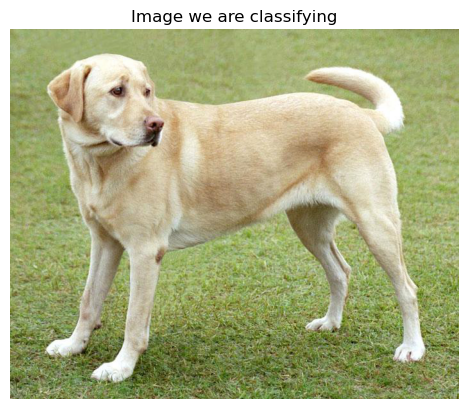

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
Top-5 predictions:
  Labrador_retriever         42.7%
  dingo                       6.2%
  Eskimo_dog                  5.6%
  kuvasz                      5.3%
  kelpie                      4.8%


In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import (
    ResNet50, preprocess_input, decode_predictions)

# Load ResNet-50 already trained on ImageNet (1.2M images, 1000 classes)
model = ResNet50(weights="imagenet")

# Grab a real photograph to classify (a Labrador retriever)
img_path = tf.keras.utils.get_file(
    "labrador.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg")

# Load the photo at full size for viewing
display_img = tf.keras.utils.load_img(img_path)

# Show the image we are about to classify
plt.imshow(display_img)
plt.axis("off")
plt.title("Image we are classifying")
plt.show()

# Resize to 224x224 for the model. We preserve the aspect ratio and center-crop
# (smart_resize) instead of squishing the rectangular photo into a square, which
# would distort the dog and confuse the model.
arr = tf.keras.utils.img_to_array(display_img)
arr = tf.keras.preprocessing.image.smart_resize(arr, (224, 224))

# Apply ResNet's preprocessing and predict
x = preprocess_input(np.expand_dims(arr, axis=0))
preds = model.predict(x)

print("Top-5 predictions:")
for _, label, prob in decode_predictions(preds, top=5)[0]:
    print(f"  {label:25s} {prob:6.1%}")

### Part 2: Transfer Learning, Fine-Tuning ResNet-50 on a New Dataset

Now we adapt ResNet-50 to a task it was never trained on: telling apart five kinds of flowers. The strategy is the standard transfer-learning recipe:

1. Download a small, real dataset (~3,670 labeled flower photos in 5 classes).
2. Load ResNet-50 **without its original 1,000-class head** and **freeze** the convolutional backbone so its learned features stay intact.
3. Attach a small new classifier for our 5 classes and train just that head. The frozen ResNet acts as a fixed **feature extractor**.

Because the backbone already knows how to detect edges, textures, and shapes, this reaches good accuracy with very little data and training. That is the practical payoff of deep residual networks.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Download a small real dataset: ~3,670 flower photos in 5 classes
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True)

IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# 2. Load pretrained ResNet-50 WITHOUT its top classifier, then freeze it
base_model = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base_model.trainable = False          # freeze the pretrained backbone

# 3. Attach a new classification head for OUR 5 flower classes
inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.resnet50.preprocess_input(inputs)  # ResNet-specific preprocessing
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# 4. Train ONLY the new head; the frozen ResNet is a fixed feature extractor
print("=== Feature-extraction training (backbone frozen) ===")
model.fit(train_ds, validation_data=val_ds, epochs=3)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Classes: ['flower_photos']
=== Feature-extraction training (backbone frozen) ===
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 920ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 893ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 897ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


#### Optional: Fine-Tune the Backbone

Feature extraction alone usually does well. To push accuracy a little further, we **unfreeze the upper layers** of ResNet-50 and keep training at a **much smaller learning rate**, so we gently specialize the pretrained features for flowers without destroying what the model already learned on ImageNet.

In [ ]:
# 5. Unfreeze the top of the backbone and continue training at a LOW learning rate
base_model.trainable = True
for layer in base_model.layers[:-20]:      # keep the early, general-purpose layers frozen
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),   # small LR protects the pretrained weights
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

print("=== Fine-tuning the top of the backbone ===")
model.fit(train_ds, validation_data=val_ds, epochs=3)

**Takeaway.** This is how ResNets are actually used in the real world: a pretrained backbone supplies powerful, general-purpose visual features, and a little fine-tuning specializes it for your specific task. It is far more practical, and far more accurate on limited data, than training a deep network from scratch. It is only possible because residual connections let those very deep backbones be trained well in the first place.

## Conclusion

In this notebook we looked at two families of techniques that make deep networks practical to train.

**Normalization** keeps the activations flowing through a network on a stable, well-behaved scale. Every method follows the same three steps (standardize using a mean and variance, then apply a learnable scale and shift), and they differ only in *which* values they pool together to compute those statistics:

- **Batch normalization** pools across the batch for each channel. It is the classic choice for CNNs trained with reasonably large batches.
- **Layer normalization** pools across each sample's own features. It is independent of batch size and is the standard in Transformers and RNNs.
- **Group normalization** pools across groups of channels within each sample. It shines when batches are small.
- **Instance normalization** pools each channel of each sample on its own and is common in style transfer and image generation.

**Residual (skip) connections** add a block's input back onto its output, so each block only has to learn the *change* it needs to make. This makes identity mappings easy to learn and gives gradients a direct path backward, which together let us train networks that are dozens or even hundreds of layers deep. **ResNets** built on this idea and remain a backbone of modern computer vision, where the most common real-world workflow is to fine-tune a pretrained ResNet rather than train one from scratch.

Put simply: normalization keeps training **stable**, and residual connections keep it **trainable at depth**. Most modern architectures, from ResNets to Transformers, rely on both.

## Additional Resources

- *Dive into Deep Learning*, [Batch Normalization](https://d2l.ai/chapter_convolutional-modern/batch-norm.html) and [Residual Networks (ResNet)](https://d2l.ai/chapter_convolutional-modern/resnet.html) chapters (the latter is the source of the nested function classes figure above).
- He, Zhang, Ren & Sun (2015), [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), the original ResNet paper.
- Wu & He (2018), [Group Normalization](https://arxiv.org/abs/1803.08494), which connects batch, layer, group, and instance normalization.
- TensorFlow, [Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning), the workflow used in the real-world example above.